Размер: (552, 736)


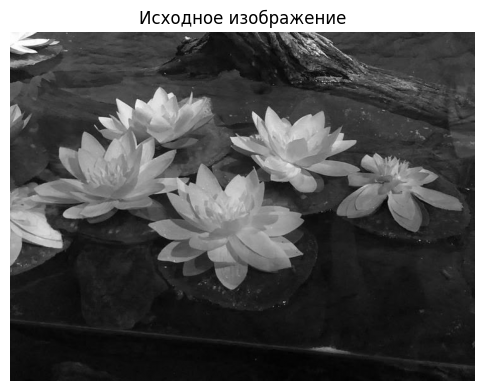

In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error as mse
import copy


image_gray = cv2.imread('sar_1.jpg', cv2.IMREAD_GRAYSCALE)


print(f"Размер: {image_gray.shape}")
plt.figure(figsize=(6, 6))
plt.imshow(image_gray, cmap='gray')
plt.title("Исходное изображение")
plt.axis('off')
plt.show()

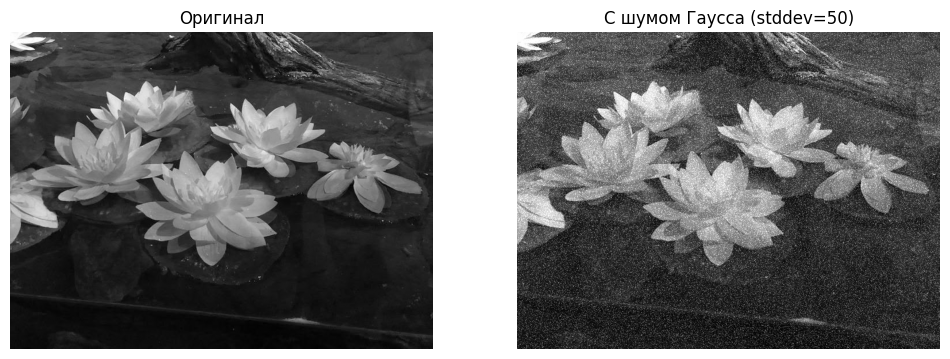

Шум Гаусса: MSE = 1220.13, SSIM = 0.1976


In [30]:
# шум гаусса
noise_gauss = np.zeros(image_gray.shape, np.uint8)


mean = 0
stddev = 50
cv2.randn(noise_gauss, mean, stddev)

image_noise_gauss = cv2.add(image_gray, noise_gauss)


plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(image_gray, cmap='gray')
plt.title("Оригинал")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image_noise_gauss, cmap='gray')
plt.title(f"С шумом Гаусса (stddev={stddev})")
plt.axis('off')
plt.show()

mse_gauss = mse(image_gray, image_noise_gauss)
ssim_gauss = ssim(image_gray, image_noise_gauss)
print(f"Шум Гаусса: MSE = {mse_gauss:.2f}, SSIM = {ssim_gauss:.4f}")

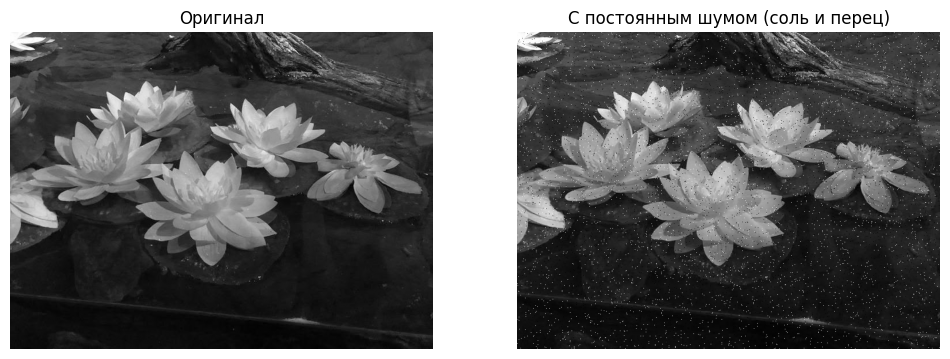

Постоянный шум: MSE = 452.39, SSIM = 0.6225


In [31]:
# постоянный шум

noise_uniform = np.random.randint(0, 101, size=(image_gray.shape[0], image_gray.shape[1]), dtype=np.uint8)


noise_uniform_image = np.ones(image_gray.shape, np.uint8) * 128 # серый


image_noise_uniform = copy.deepcopy(image_gray)
noise = np.random.randint(0, 101, size=(image_gray.shape[0], image_gray.shape[1]), dtype=int)


zeros_pixel = np.where(noise == 0) # чёрные точки
ones_pixel = np.where(noise == 100) # белые точки


image_noise_uniform[zeros_pixel] = 0
image_noise_uniform[ones_pixel] = 255


plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(image_gray, cmap='gray')
plt.title("Оригинал")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image_noise_uniform, cmap='gray')
plt.title("С постоянным шумом")
plt.axis('off')
plt.show()

mse_uniform = mse(image_gray, image_noise_uniform)
ssim_uniform = ssim(image_gray, image_noise_uniform)
print(f"Постоянный шум: MSE = {mse_uniform:.2f}, SSIM = {ssim_uniform:.4f}")

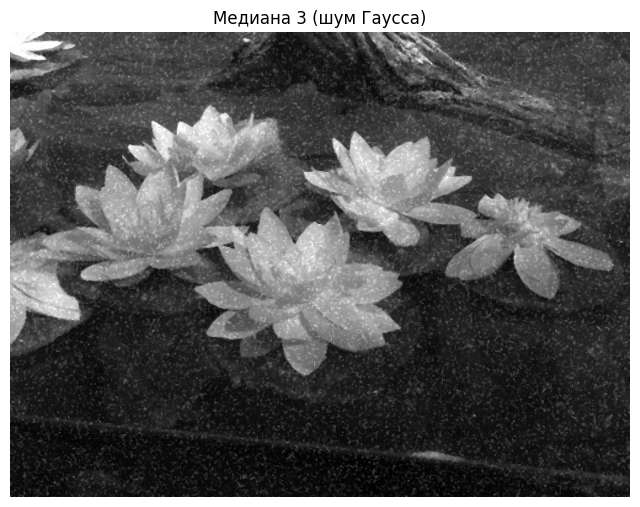

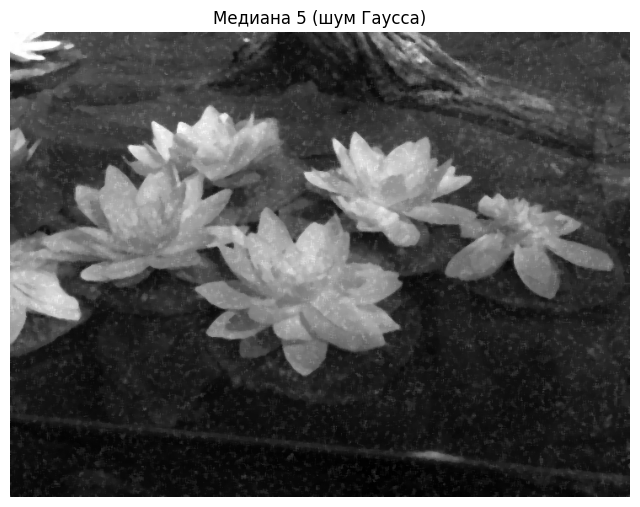

1) Медиана 3:
MSE = 253.12
SSIM = 0.5098
2) Медиана 5:
MSE = 170.33
SSIM = 0.6785


In [32]:
# тест фильтров на шуме гаусса

# медианный фильтр
median_gauss_3 = cv2.medianBlur(image_noise_gauss, 3)
median_gauss_5 = cv2.medianBlur(image_noise_gauss, 5)

# фильтр Гаусса
gauss_gauss_5 = cv2.GaussianBlur(image_noise_gauss, (5, 5), 0)
gauss_gauss_9 = cv2.GaussianBlur(image_noise_gauss, (9, 9), 0)

# билатеральный фильтр
bilateral_gauss_9 = cv2.bilateralFilter(image_noise_gauss, 9, 75, 75)
bilateral_gauss_15 = cv2.bilateralFilter(image_noise_gauss, 15, 75, 75)

# фильтр нелокальных средних
nlm_gauss_10 = cv2.fastNlMeansDenoising(image_noise_gauss, h=10)
nlm_gauss_20 = cv2.fastNlMeansDenoising(image_noise_gauss, h=20)

plt.figure(figsize=(8, 8))
plt.imshow(median_gauss_3, cmap='gray')
plt.title("Медиана 3 (шум Гаусса)")
plt.axis('off')
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(median_gauss_5, cmap='gray')
plt.title("Медиана 5 (шум Гаусса)")
plt.axis('off')
plt.show()

print("1) Медиана 3:")
print("MSE =", round(mse(image_gray, median_gauss_3), 2))
print("SSIM =", round(ssim(image_gray, median_gauss_3), 4))
print("2) Медиана 5:")
print("MSE =", round(mse(image_gray, median_gauss_5), 2))
print("SSIM =", round(ssim(image_gray, median_gauss_5), 4))

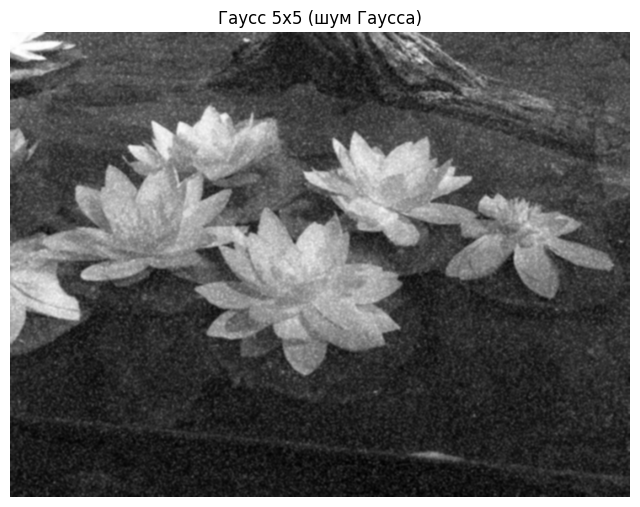

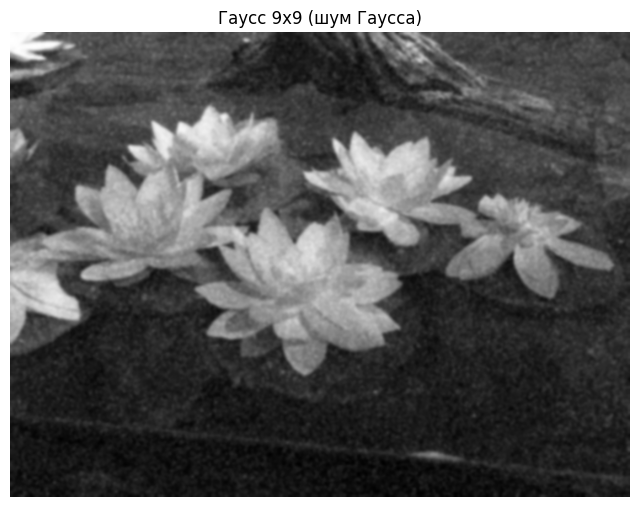

3) Гаусс 5x5:
MSE = 487.5
SSIM = 0.5882
4) Гаусс 9x9:
MSE = 482.44
SSIM = 0.6843


In [33]:
plt.figure(figsize=(8, 8))
plt.imshow(gauss_gauss_5, cmap='gray')
plt.title("Гаусс 5x5 (шум Гаусса)")
plt.axis('off')
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(gauss_gauss_9, cmap='gray')
plt.title("Гаусс 9x9 (шум Гаусса)")
plt.axis('off')
plt.show()

print("3) Гаусс 5x5:")
print("MSE =", round(mse(image_gray, gauss_gauss_5), 2))
print("SSIM =", round(ssim(image_gray, gauss_gauss_5), 4))
print("4) Гаусс 9x9:")
print("MSE =", round(mse(image_gray, gauss_gauss_9), 2))
print("SSIM =", round(ssim(image_gray, gauss_gauss_9), 4))

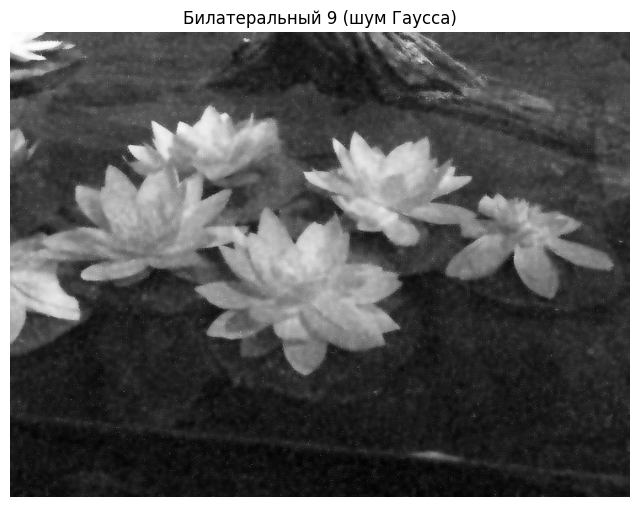

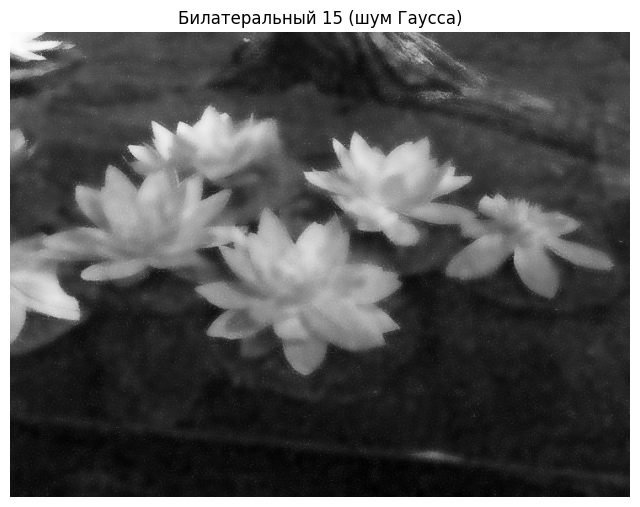

5) Билатеральный 9:
MSE = 403.9
SSIM = 0.634
6) Билатеральный 15:
MSE = 422.88
SSIM = 0.6182


In [34]:
plt.figure(figsize=(8, 8))
plt.imshow(bilateral_gauss_9, cmap='gray')
plt.title("Билатеральный 9 (шум Гаусса)")
plt.axis('off')
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(bilateral_gauss_15, cmap='gray')
plt.title("Билатеральный 15 (шум Гаусса)")
plt.axis('off')
plt.show()

print("5) Билатеральный 9:")
print("MSE =", round(mse(image_gray, bilateral_gauss_9), 2))
print("SSIM =", round(ssim(image_gray, bilateral_gauss_9), 4))
print("6) Билатеральный 15:")
print("MSE =", round(mse(image_gray, bilateral_gauss_15), 2))
print("SSIM =", round(ssim(image_gray, bilateral_gauss_15), 4))

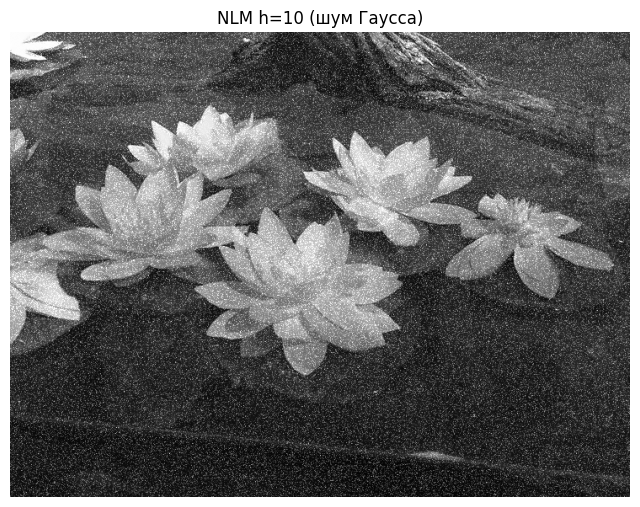

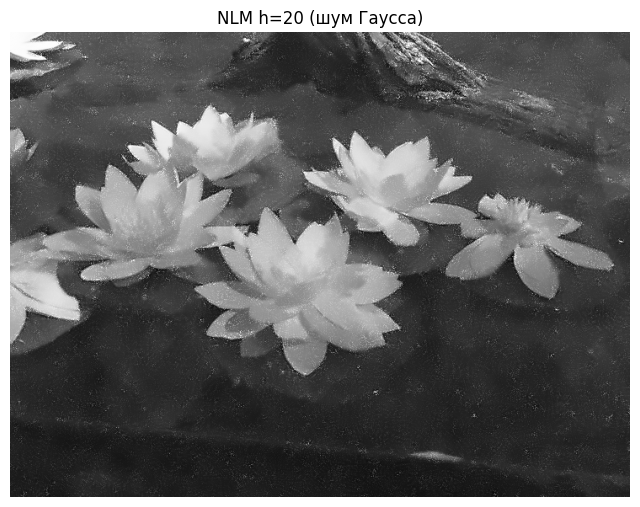

7) Фильтр нелокальных средних h=10:
MSE = 1219.17
SSIM = 0.1982
8) Фильтр нелокальных средних h=20:
MSE = 501.0
SSIM = 0.5533


In [35]:
plt.figure(figsize=(8, 8))
plt.imshow(nlm_gauss_10, cmap='gray')
plt.title("NLM h=10 (шум Гаусса)")
plt.axis('off')
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(nlm_gauss_20, cmap='gray')
plt.title("NLM h=20 (шум Гаусса)")
plt.axis('off')
plt.show()

print("7) Фильтр нелокальных средних h=10:")
print("MSE =", round(mse(image_gray, nlm_gauss_10), 2))
print("SSIM =", round(ssim(image_gray, nlm_gauss_10), 4))
print("8) Фильтр нелокальных средних h=20:")
print("MSE =", round(mse(image_gray, nlm_gauss_20), 2))
print("SSIM =", round(ssim(image_gray, nlm_gauss_20), 4))

In [36]:
best_ssim = 0
best_filter = ""

all_gauss = [
    ("Медиана 3", median_gauss_3),
    ("Медиана 5", median_gauss_5),
    ("Гаусс 5x5", gauss_gauss_5),
    ("Гаусс 9x9", gauss_gauss_9),
    ("Билатеральный 9", bilateral_gauss_9),
    ("Билатеральный 15", bilateral_gauss_15),
    ("Фильтр нелокальных средних h=10", nlm_gauss_10),
    ("Фильтр нелокальных средних h=20", nlm_gauss_20),
]

# ищу макс SSIM
for title, img in all_gauss:
    ssim_val = ssim(image_gray, img)
    if ssim_val > best_ssim:
        best_ssim = ssim_val
        best_filter = title

print("Бест оф зе бест для шума Гаусса:", best_filter)
print("SSIM =", round(best_ssim, 4))

Бест оф зе бест для шума Гаусса: Гаусс 9x9
SSIM = 0.6843


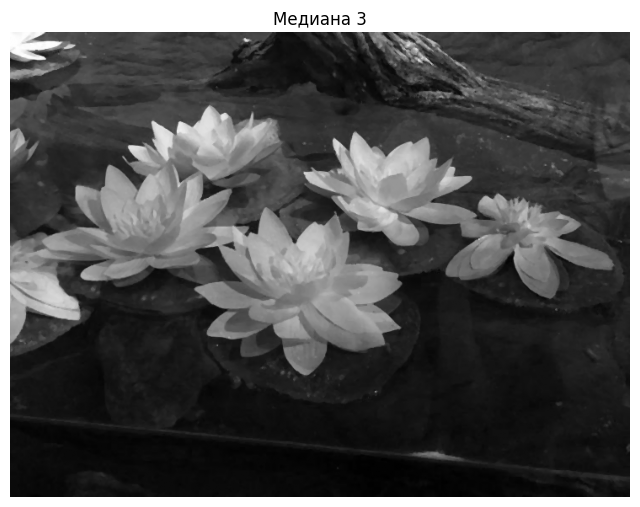

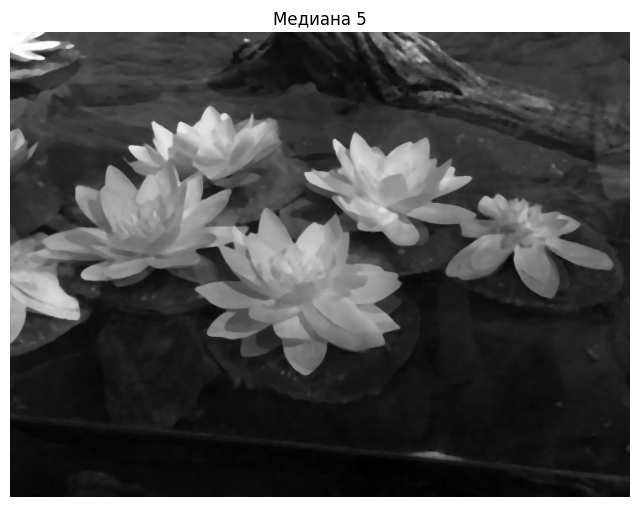

1) Медиана 3:
MSE = 18.2
SSIM = 0.9605
2) Медиана 5:
MSE = 40.72
SSIM = 0.9111


In [37]:
# тесты фильтров на постоянном шуме

# медианный фильтр
median_uniform_3 = cv2.medianBlur(image_noise_uniform, 3)
median_uniform_5 = cv2.medianBlur(image_noise_uniform, 5)

# фильтр Гаусса
gauss_uniform_5 = cv2.GaussianBlur(image_noise_uniform, (5, 5), 0)
gauss_uniform_9 = cv2.GaussianBlur(image_noise_uniform, (9, 9), 0)

# билатеральный фильтр
bilateral_uniform_9 = cv2.bilateralFilter(image_noise_uniform, 9, 75, 75)
bilateral_uniform_15 = cv2.bilateralFilter(image_noise_uniform, 15, 75, 75)

# фильтр нелокальных средних (NLM)
nlm_uniform_10 = cv2.fastNlMeansDenoising(image_noise_uniform, h=10)
nlm_uniform_20 = cv2.fastNlMeansDenoising(image_noise_uniform, h=20)

plt.figure(figsize=(8, 8))
plt.imshow(median_uniform_3, cmap='gray')
plt.title("Медиана 3")
plt.axis('off')
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(median_uniform_5, cmap='gray')
plt.title("Медиана 5")
plt.axis('off')
plt.show()

print("1) Медиана 3:")
print("MSE =", round(mse(image_gray, median_uniform_3), 2))
print("SSIM =", round(ssim(image_gray, median_uniform_3), 4))
print("2) Медиана 5:")
print("MSE =", round(mse(image_gray, median_uniform_5), 2))
print("SSIM =", round(ssim(image_gray, median_uniform_5), 4))

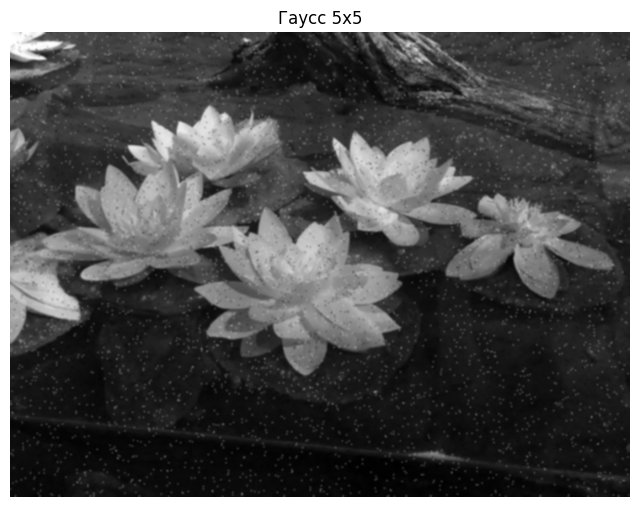

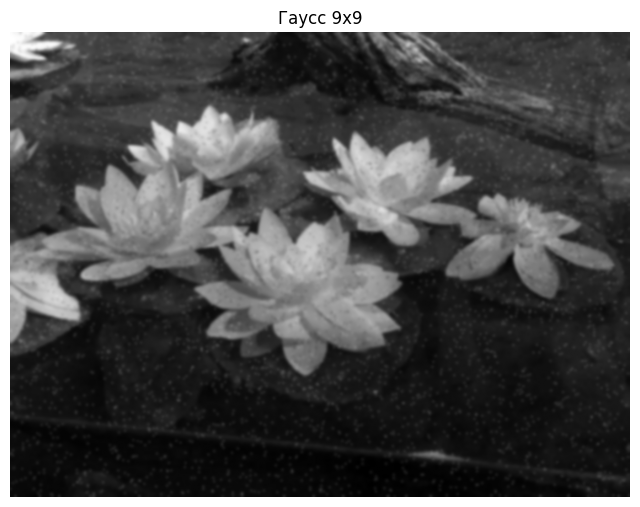

3) Гаусс 5x5:
MSE = 69.94
SSIM = 0.7796
4) Гаусс 9x9:
MSE = 82.58
SSIM = 0.8115


In [38]:
plt.figure(figsize=(8, 8))
plt.imshow(gauss_uniform_5, cmap='gray')
plt.title("Гаусс 5x5")
plt.axis('off')
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(gauss_uniform_9, cmap='gray')
plt.title("Гаусс 9x9")
plt.axis('off')
plt.show()

print("3) Гаусс 5x5:")
print("MSE =", round(mse(image_gray, gauss_uniform_5), 2))
print("SSIM =", round(ssim(image_gray, gauss_uniform_5), 4))
print("4) Гаусс 9x9:")
print("MSE =", round(mse(image_gray, gauss_uniform_9), 2))
print("SSIM =", round(ssim(image_gray, gauss_uniform_9), 4))

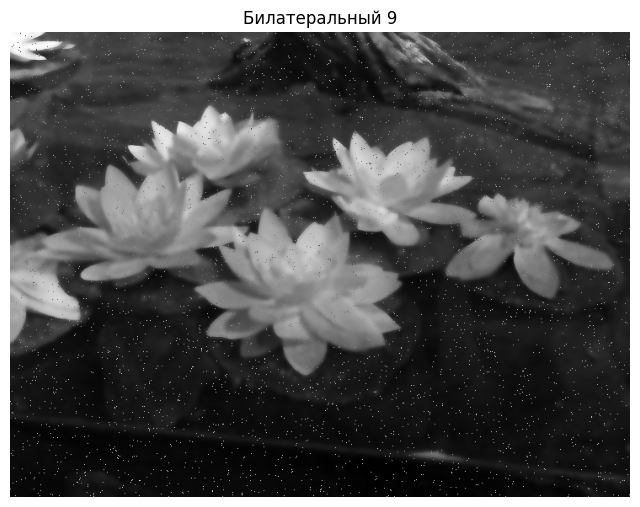

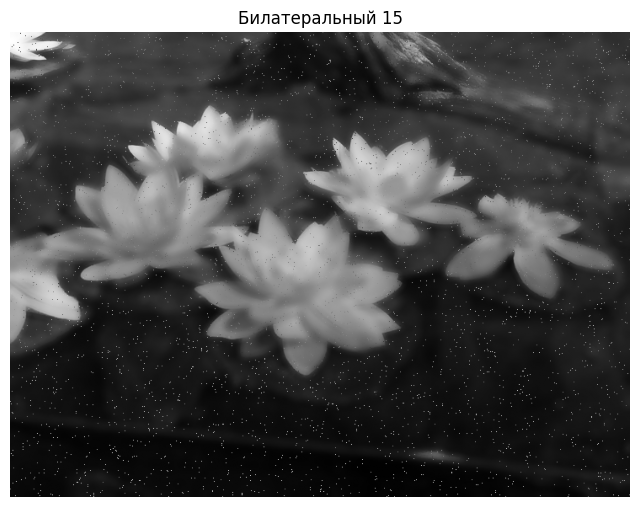

5) Билатеральный 9:
MSE = 227.3
SSIM = 0.6556
6) Билатеральный 15:
MSE = 203.26
SSIM = 0.6247


In [39]:
plt.figure(figsize=(8, 8))
plt.imshow(bilateral_uniform_9, cmap='gray')
plt.title("Билатеральный 9")
plt.axis('off')
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(bilateral_uniform_15, cmap='gray')
plt.title("Билатеральный 15")
plt.axis('off')
plt.show()

print("5) Билатеральный 9:")
print("MSE =", round(mse(image_gray, bilateral_uniform_9), 2))
print("SSIM =", round(ssim(image_gray, bilateral_uniform_9), 4))
print("6) Билатеральный 15:")
print("MSE =", round(mse(image_gray, bilateral_uniform_15), 2))
print("SSIM =", round(ssim(image_gray, bilateral_uniform_15), 4))

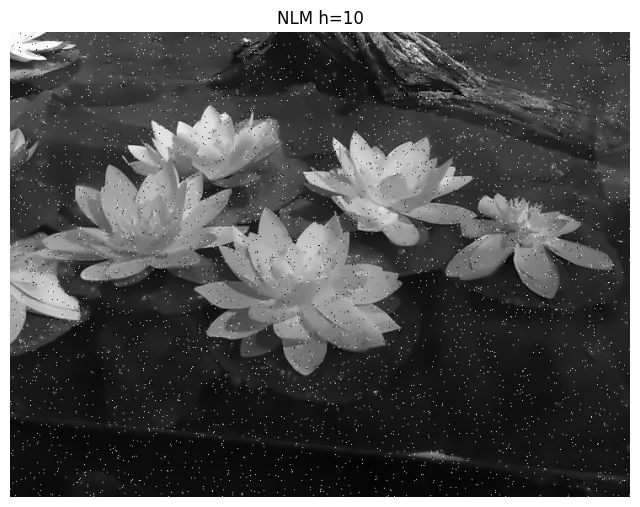

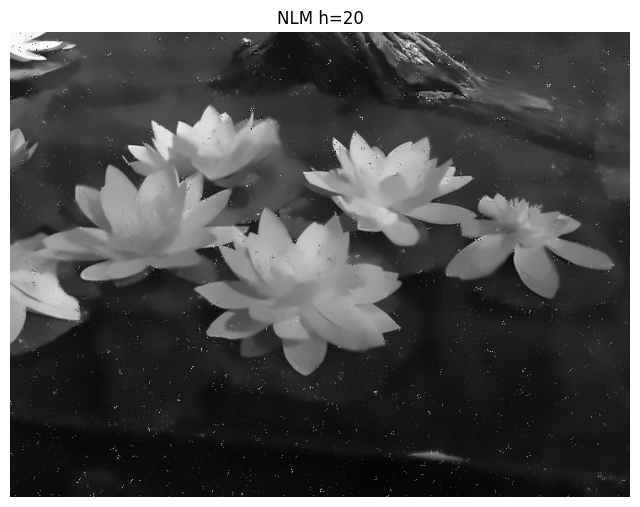

7) Фильтр нелокальных средних h=10:
MSE = 443.19
SSIM = 0.6183
8) Фильтр нелокальных средних h=20:
MSE = 117.5
SSIM = 0.7349


In [40]:
plt.figure(figsize=(8, 8))
plt.imshow(nlm_uniform_10, cmap='gray')
plt.title("NLM h=10")
plt.axis('off')
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(nlm_uniform_20, cmap='gray')
plt.title("NLM h=20")
plt.axis('off')
plt.show()

print("7) Фильтр нелокальных средних h=10:")
print("MSE =", round(mse(image_gray, nlm_uniform_10), 2))
print("SSIM =", round(ssim(image_gray, nlm_uniform_10), 4))
print("8) Фильтр нелокальных средних h=20:")
print("MSE =", round(mse(image_gray, nlm_uniform_20), 2))
print("SSIM =", round(ssim(image_gray, nlm_uniform_20), 4))

In [41]:
best_ssim_uniform = 0
best_filter_uniform = ""

all_uniform = [
    ("Медиана 3", median_uniform_3),
    ("Медиана 5", median_uniform_5),
    ("Гаусс 5x5", gauss_uniform_5),
    ("Гаусс 9x9", gauss_uniform_9),
    ("Билатеральный 9", bilateral_uniform_9),
    ("Билатеральный 15", bilateral_uniform_15),
    ("Фильтр нелокальных средних h=10", nlm_uniform_10),
    ("Фильтр нелокальных средних h=20", nlm_uniform_20),
]

for title, img in all_uniform:
    ssim_val = ssim(image_gray, img)
    if ssim_val > best_ssim_uniform:
        best_ssim_uniform = ssim_val
        best_filter_uniform = title

print("Бест оф зе бест фильтр для постоянного шума:", best_filter_uniform)
print("SSIM =", round(best_ssim_uniform, 4))

Бест оф зе бест фильтр для постоянного шума: Медиана 3
SSIM = 0.9605
